In [20]:
from google.colab import files
uploded = files.upload()

Saving Online Retail.xlsx to Online Retail (1).xlsx


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [25]:
df = pd.read_excel("Online Retail.xlsx")

In [26]:
df.head()



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [27]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [29]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [30]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [31]:
df["Description"] = df["Description"].fillna(df["Description"].mode())
df["CustomerID"] = df["CustomerID"].fillna(df["CustomerID"].mode()[0])

In [32]:
df.duplicated().sum()

np.int64(5268)

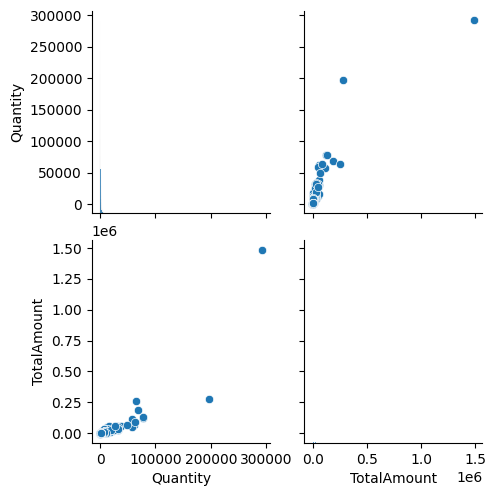

In [35]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

customer = df.groupby("CustomerID")[["Quantity","TotalAmount"]].sum()

sns.pairplot(customer)
plt.show()

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer)

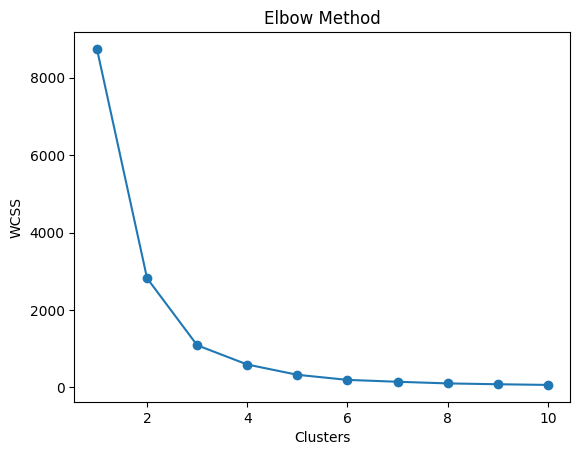

In [37]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [38]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

customer["Cluster"] = clusters

In [39]:
print(kmeans.cluster_centers_)

[[-3.76490065e-02 -2.70708726e-02]
 [ 4.54139216e+01  6.21102438e+01]
 [ 1.18773396e+01  5.59458317e+00]]


In [40]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score =", score)

Silhouette Score = 0.9813712310131796


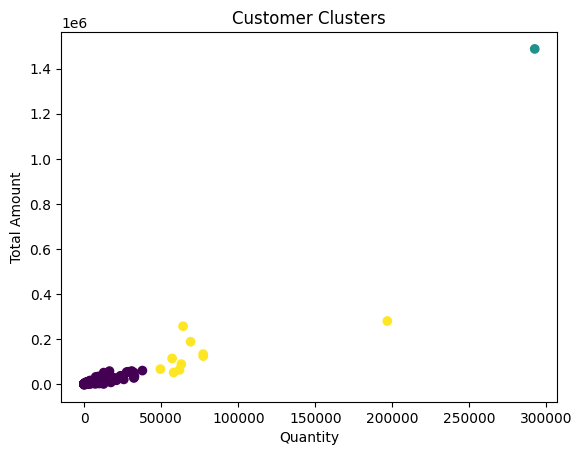

In [41]:
plt.scatter(customer["Quantity"],
            customer["TotalAmount"],
            c=customer["Cluster"],
            cmap="viridis")

plt.title("Customer Clusters")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.show()

In [42]:
print(customer["Cluster"].value_counts())

Cluster
0    4361
2      10
1       1
Name: count, dtype: int64


In [44]:
print(customer.groupby("Cluster").mean())

             Quantity   TotalAmount
Cluster                            
0           942.55446  1.582000e+03
1        292427.00000  1.488023e+06
2         77354.30000  1.360625e+05
